<a href="https://colab.research.google.com/github/leolabs-id/datascience-learning-homework/blob/main/Final_Project_Group_1_Digital_Skola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Importing Data and Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
#machine learning libraries:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import cross_val_score, cross_val_predict

#evaluation
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score,f1_score, precision_score, recall_score
from sklearn.metrics import precision_recall_curve

import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_data= pd.read_csv('adult.csv')
test_data= pd.read_csv('adult.test.csv')

In [ ]:
train_data.head()

,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
test_data.head()

,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0.1,40,United-States,<=50K.
0,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
1,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
2,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
3,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.
4,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K.


In [ ]:
columns=train_data.columns
test_data.columns=columns

In [ ]:
df = pd.concat([train_data, test_data], axis= 0)

In [ ]:
df.head()

,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.describe()

,Age,Final Weight,EducationNum,Capital Gain,capital loss,Hours per Week
count,48841.000000,4.884100e+04,48841.000000,48841.000000,48841.000000,48841.000000
mean,38.643865,1.896634e+05,10.078152,1079.089720,87.504105,40.422391
std,13.710511,1.056050e+05,2.570961,7452.093748,403.008483,12.391571
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175490e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781420e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376460e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48841 entries, 0 to 16279
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             48841 non-null  int64 
 1   Workclass       48841 non-null  object
 2   Final Weight    48841 non-null  int64 
 3   Education       48841 non-null  object
 4   EducationNum    48841 non-null  int64 
 5   Marital Status  48841 non-null  object
 6   Occupation      48841 non-null  object
 7   Relationship    48841 non-null  object
 8   Race            48841 non-null  object
 9   Gender          48841 non-null  object
 10  Capital Gain    48841 non-null  int64 
 11  capital loss    48841 non-null  int64 
 12  Hours per Week  48841 non-null  int64 
 13  Native Country  48841 non-null  object
 14  Income          48841 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


In [ ]:
df['Workclass'].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [ ]:
df['Marital Status'].unique()

array([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'], dtype=object)

In [ ]:
df['Occupation'].unique()

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [ ]:
df['Race'].unique()

array([' White', ' Black', ' Asian-Pac-Islander', ' Amer-Indian-Eskimo',
       ' Other'], dtype=object)

In [ ]:
df['Income'].unique()

array([' <=50K', ' >50K', ' <=50K.', ' >50K.'], dtype=object)

# **2. Data Pre-Processing**

In [ ]:
df_copy1= df.copy()

In [ ]:
for col in columns:
    if df[col].dtype in ['O']:
        df[col]=df[col].str.strip()

In [ ]:
df['Workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', '?', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [ ]:
df.replace("?", np.nan, inplace=True)

In [ ]:
df

,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
16276,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
16277,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
16278,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [ ]:
df.isna().sum()

,0
Age,0
Workclass,2799
Final Weight,0
Education,0
EducationNum,0
Marital Status,0
Occupation,2809
Relationship,0
Race,0
Gender,0


In [ ]:
df[df['Occupation'].isna() & ~df['Workclass'].isna()]

,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
5361,18,Never-worked,206359,10th,6,Never-married,NaN,Own-child,White,Male,0,0,40,United-States,<=50K
10845,23,Never-worked,188535,7th-8th,4,Divorced,NaN,Not-in-family,White,Male,0,0,35,United-States,<=50K
14772,17,Never-worked,237272,10th,6,Never-married,NaN,Own-child,White,Male,0,0,30,United-States,<=50K
20337,18,Never-worked,157131,11th,7,Never-married,NaN,Own-child,White,Female,0,0,10,United-States,<=50K
23232,20,Never-worked,462294,Some-college,10,Never-married,NaN,Own-child,Black,Male,0,0,40,United-States,<=50K
32304,30,Never-worked,176673,HS-grad,9,Married-civ-spouse,NaN,Wife,Black,Female,0,0,40,United-States,<=50K
32314,18,Never-worked,153663,Some-college,10,Never-married,NaN,Own-child,White,Male,0,0,4,United-States,<=50K
8784,17,Never-worked,131593,11th,7,Never-married,NaN,Own-child,Black,Female,0,0,20,United-States,<=50K.
11606,20,Never-worked,273905,HS-grad,9,Married-spouse-absent,NaN,Other-relative,White,Male,0,0,35,United-States,<=50K.
13897,18,Never-worked,162908,11th,7,Never-married,NaN,Own-child,White,Male,0,0,35,United-States,<=50K.


In [ ]:
df['Workclass'].value_counts()

,count
Workclass,
Private,33905
Self-emp-not-inc,3862
Local-gov,3136
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


In [ ]:
df[df['Workclass']=='Never-worked']= df[df['Workclass']=='Never-worked'].fillna('No-occupation')
df[df['Workclass']=='Never-worked']

,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
5361,18,Never-worked,206359,10th,6,Never-married,No-occupation,Own-child,White,Male,0,0,40,United-States,<=50K
10845,23,Never-worked,188535,7th-8th,4,Divorced,No-occupation,Not-in-family,White,Male,0,0,35,United-States,<=50K
14772,17,Never-worked,237272,10th,6,Never-married,No-occupation,Own-child,White,Male,0,0,30,United-States,<=50K
20337,18,Never-worked,157131,11th,7,Never-married,No-occupation,Own-child,White,Female,0,0,10,United-States,<=50K
23232,20,Never-worked,462294,Some-college,10,Never-married,No-occupation,Own-child,Black,Male,0,0,40,United-States,<=50K
32304,30,Never-worked,176673,HS-grad,9,Married-civ-spouse,No-occupation,Wife,Black,Female,0,0,40,United-States,<=50K
32314,18,Never-worked,153663,Some-college,10,Never-married,No-occupation,Own-child,White,Male,0,0,4,United-States,<=50K
8784,17,Never-worked,131593,11th,7,Never-married,No-occupation,Own-child,Black,Female,0,0,20,United-States,<=50K.
11606,20,Never-worked,273905,HS-grad,9,Married-spouse-absent,No-occupation,Other-relative,White,Male,0,0,35,United-States,<=50K.
13897,18,Never-worked,162908,11th,7,Never-married,No-occupation,Own-child,White,Male,0,0,35,United-States,<=50K.


In [ ]:
df['Occupation'].isna().sum()

np.int64(2799)

In [ ]:
df[df['Occupation'].isna() & df['Workclass'].isna()]

,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
27,54,NaN,180211,Some-college,10,Married-civ-spouse,NaN,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
61,32,NaN,293936,7th-8th,4,Married-spouse-absent,NaN,Not-in-family,White,Male,0,0,40,NaN,<=50K
69,25,NaN,200681,Some-college,10,Never-married,NaN,Own-child,White,Male,0,0,40,United-States,<=50K
77,67,NaN,212759,10th,6,Married-civ-spouse,NaN,Husband,White,Male,0,0,2,United-States,<=50K
106,17,NaN,304873,10th,6,Never-married,NaN,Own-child,White,Female,34095,0,32,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16120,61,NaN,265201,Some-college,10,Married-civ-spouse,NaN,Husband,White,Male,0,0,14,United-States,<=50K.
16207,21,NaN,212661,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.
16238,73,NaN,144872,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,25,Canada,<=50K.
16250,81,NaN,26711,Assoc-voc,11,Married-civ-spouse,NaN,Husband,White,Male,2936,0,20,United-States,<=50K.


---
>**Karena Workclass dan Occupation sama-sama kosong (NaN) dan proporsinya cukup besar sekitar 5%, maka diisi "Unknown" karena tidak ada dasar yang valid untuk menentukan kategorinya.**
---

In [ ]:
df['Workclass'] = df['Workclass'].fillna('Unknown')
df['Occupation'] = df['Occupation'].fillna('Unknown')

In [ ]:
df['Native Country'].value_counts()[0:5]

,count
Native Country,
United-States,43831
Mexico,951
Philippines,295
Germany,206
Puerto-Rico,184


In [ ]:
df['Native Country'].value_counts(normalize=True) * 100

,proportion
Native Country,
United-States,91.345032
Mexico,1.981911
Philippines,0.614788
Germany,0.429310
Puerto-Rico,0.383461
Canada,0.379293
El-Salvador,0.323024
India,0.314688
Cuba,0.287596


---
>**91.3% data Native Country adalah United-States, sehingga dibuat simplifikasi menjadi 2 kategori saja United-States dan Non US**
---

In [ ]:
df['Native Country'] = df['Native Country'].where(
    df['Native Country'] == 'United-States',
    'Non US'
)

In [ ]:
df['Native Country'].unique()

array(['United-States', 'Non US'], dtype=object)

In [ ]:
df['Native Country'].isna().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48841 entries, 0 to 16279
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             48841 non-null  int64 
 1   Workclass       48841 non-null  object
 2   Final Weight    48841 non-null  int64 
 3   Education       48841 non-null  object
 4   EducationNum    48841 non-null  int64 
 5   Marital Status  48841 non-null  object
 6   Occupation      48841 non-null  object
 7   Relationship    48841 non-null  object
 8   Race            48841 non-null  object
 9   Gender          48841 non-null  object
 10  Capital Gain    48841 non-null  int64 
 11  capital loss    48841 non-null  int64 
 12  Hours per Week  48841 non-null  int64 
 13  Native Country  48841 non-null  object
 14  Income          48841 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


In [ ]:
df.isna().sum()

,0
Age,0
Workclass,0
Final Weight,0
Education,0
EducationNum,0
Marital Status,0
Occupation,0
Relationship,0
Race,0
Gender,0


In [ ]:
df['Income'] = df['Income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

In [ ]:
df['Income'].unique()


array(['<=50K', '>50K'], dtype=object)

In [ ]:
df['Income'].value_counts(normalize=True) * 100

,proportion
Income,
<=50K,76.071334
>50K,23.928666


# **3. Exploratory Data Analysis**

In [ ]:
num_cols = ['Age', 'Final Weight', 'EducationNum',
            'Capital Gain', 'capital loss', 'Hours per Week']

df[num_cols].describe()

,Age,Final Weight,EducationNum,Capital Gain,capital loss,Hours per Week
count,48841.000000,4.884100e+04,48841.000000,48841.000000,48841.000000,48841.000000
mean,38.643865,1.896634e+05,10.078152,1079.089720,87.504105,40.422391
std,13.710511,1.056050e+05,2.570961,7452.093748,403.008483,12.391571
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175490e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781420e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376460e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## Data Numerical

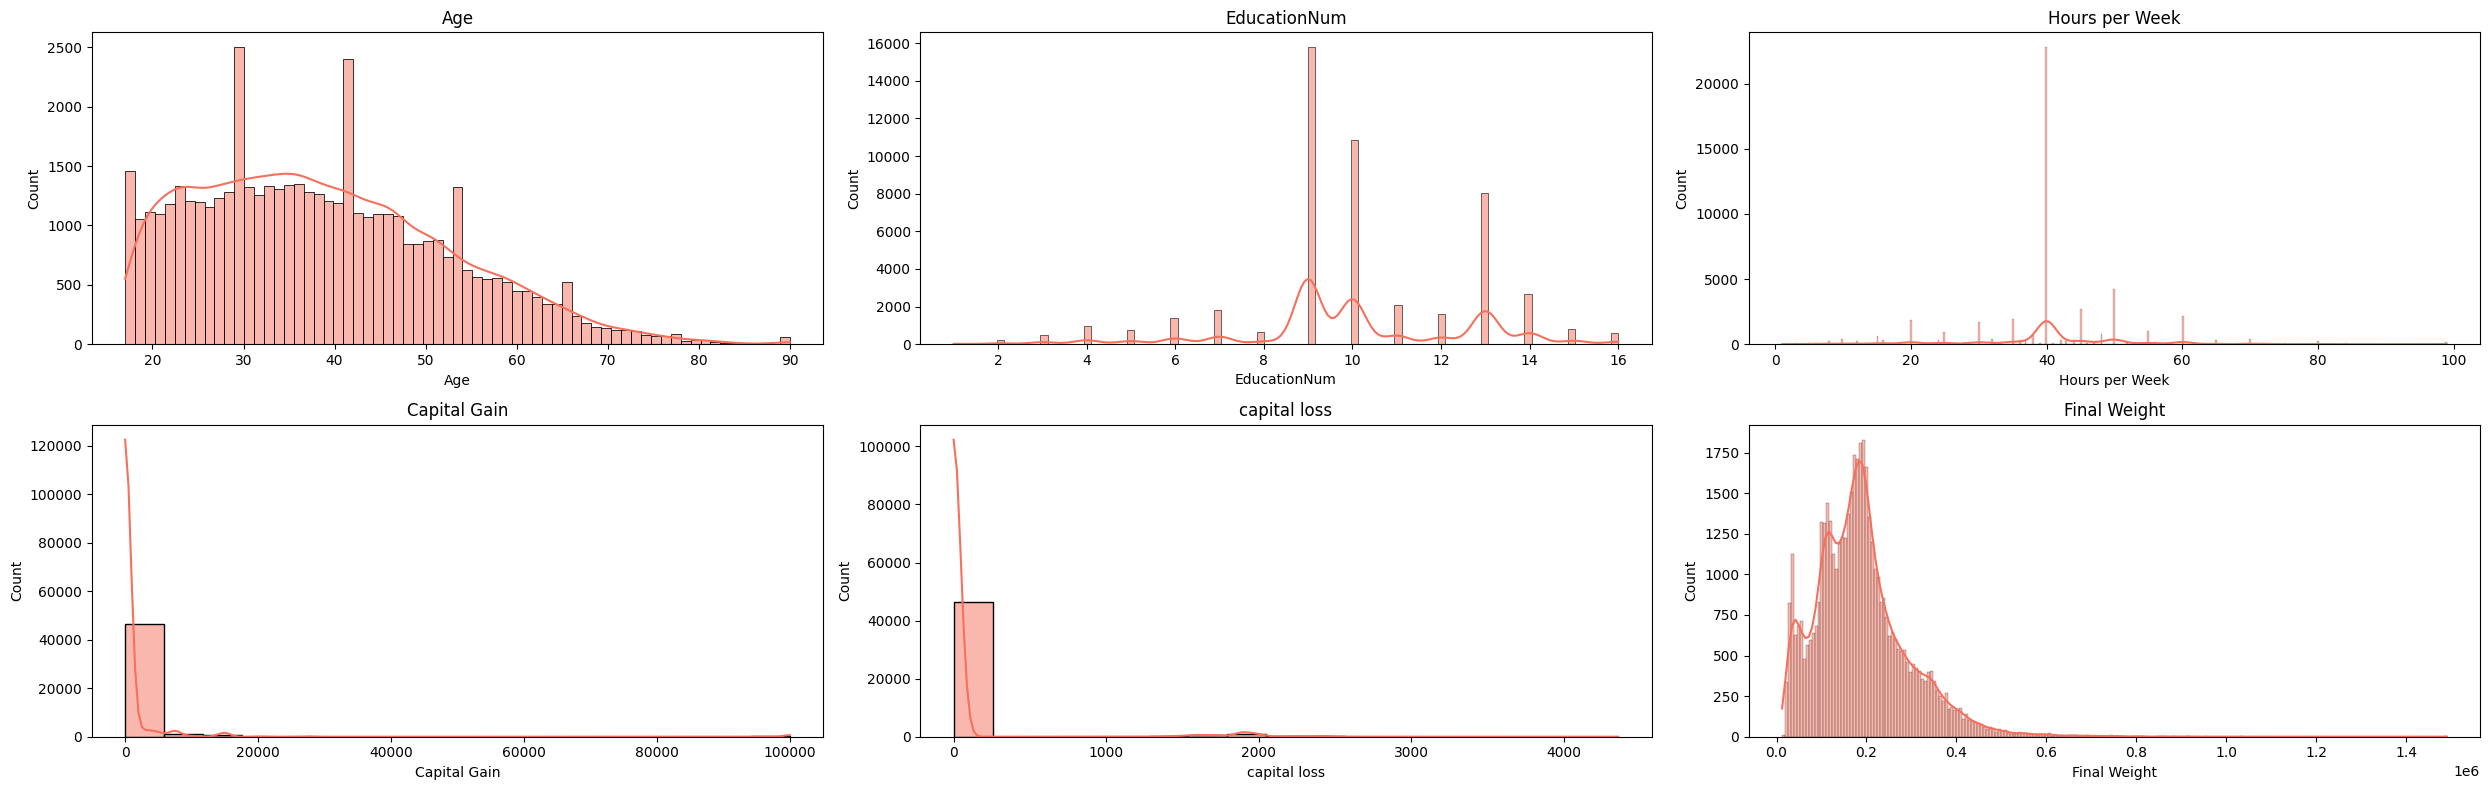

In [ ]:
# Distribusi Fitur Numerik

magma_color = plt.cm.magma(0.7)

fig, axes = plt.subplots(2, 3, figsize=(25, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=magma_color)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


---
>**Kesimpulan Distribusi Numerik**
1. Age : Mayoritas berada di usia 20 - 50 tahun
2. Final weight : Final Weight adalah bobot sampling yang digunakan oleh US Census untuk merepresentasikan populasi sebenarnya. Satu baris data tidak selalu mewakili 1 orang. (Jujur ga ngerti ini apaan)
3. EducationNum : Paling banyak pada nilai 9–10–13 (SMA - Some College - Bachelor)
4. Capital Gain : Dominan 0
5. Capital loss : Dominan 0
6. Hours per Week : Terpisat di 40 jam/minggu, distribusi normal
---

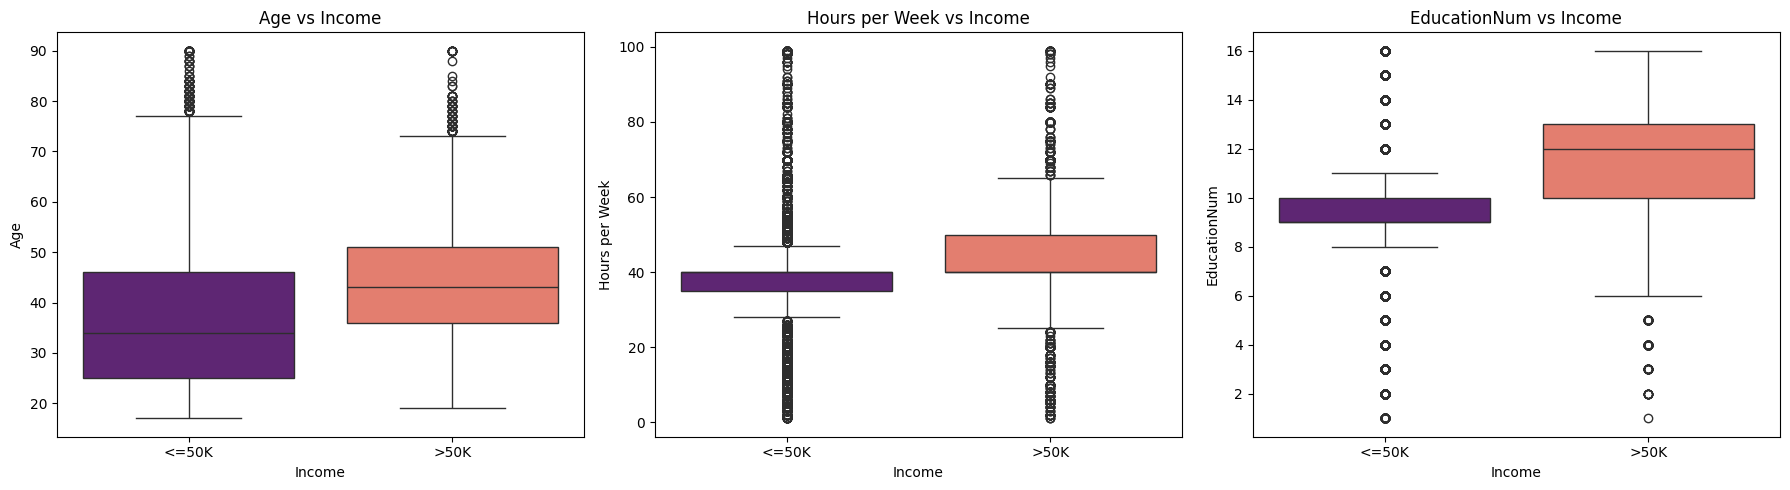

In [ ]:
palette_magma = [plt.cm.magma(0.3), plt.cm.magma(0.7)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Income', y='Age', data=df, ax=axes[0], palette= palette_magma )
axes[0].set_title('Age vs Income')

sns.boxplot(x='Income', y='Hours per Week', data=df,  ax=axes[1], palette= palette_magma)
axes[1].set_title('Hours per Week vs Income')

sns.boxplot(x='Income', y='EducationNum', data=df, ax=axes[2], palette= palette_magma)
axes[2].set_title('EducationNum vs Income')


plt.tight_layout()
plt.show()


---
>**Kesimpulan**
Orang yang berpenghasilan >50k cenderung berusia lebih tua, berkerja lebih dari 40 jam/minggu dan memiliki tingkat pendidikan yang lebih tinggi. Pendidikan memiliki pengaruh paling signifikan terhadap income
---


---

***Insight Grafik Boxplot (Age, Hours per Week, EducationNum vs Income)***

**Age vs Income**

* Individu dengan **income >50K** memiliki **median usia lebih tinggi** dibandingkan kelompok ≤50K.
* Kelompok ≤50K didominasi usia lebih muda, menunjukkan fase awal atau menengah karier.
* Hal ini mengindikasikan bahwa **pengalaman kerja yang seiring bertambahnya usia** berkontribusi terhadap peningkatan pendapatan.

---

**Hours per Week vs Income**

* Kelompok **income >50K** cenderung bekerja **lebih lama**, dengan median jam kerja sekitar **40–50 jam per minggu**.
* Kelompok ≤50K umumnya bekerja mendekati jam kerja standar (±40 jam/minggu).
* Jam kerja yang lebih panjang berkorelasi positif dengan peluang memperoleh pendapatan yang lebih tinggi.

---
**EducationNum vs Income**

* Perbedaan distribusi **EducationNum** antara kedua kelompok income terlihat paling jelas.
* Individu dengan **income >50K** memiliki tingkat pendidikan yang lebih tinggi (Bachelor ke atas).
* Pendidikan menunjukkan pengaruh paling signifikan terhadap tingkat pendapatan dibandingkan usia dan jam kerja.

---

 **Kesimpulan Utama**

> Individu dengan pendapatan lebih dari 50K cenderung berusia lebih tua, bekerja lebih lama, dan memiliki tingkat pendidikan yang lebih tinggi. Dari ketiga variabel yang dianalisis, **tingkat pendidikan merupakan faktor yang paling dominan dalam membedakan kelompok pendapatan**.

---

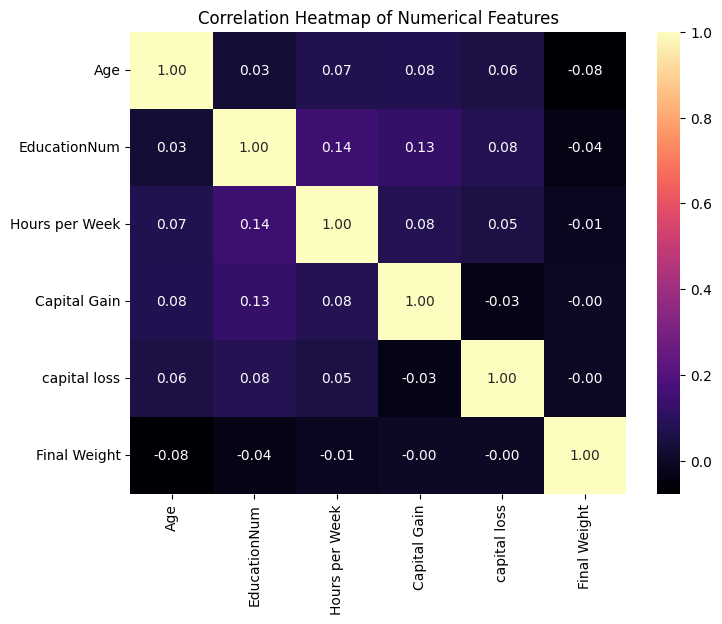

In [ ]:
num_cols = [
    'Age', 'EducationNum', 'Hours per Week',
    'Capital Gain', 'capital loss', 'Final Weight'
]

plt.figure(figsize=(8,6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='magma',
    fmt='.2f'
)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


---

***Insight Correlation Heatmap (Fitur Numerik)***

**Hubungan antar fitur numerik**

* Secara umum, **tidak terdapat korelasi yang kuat** antar fitur numerik.
* Sebagian besar nilai korelasi berada di rentang **-0.1 hingga 0.15**, yang menunjukkan hubungan **lemah**.

---

**EducationNum**

* Memiliki korelasi positif tertinggi (meskipun lemah) dengan:

  * **Hours per Week (0.14)**
  * **Capital Gain (0.13)**
* Hal ini menunjukkan bahwa individu dengan tingkat pendidikan lebih tinggi cenderung:

  * Bekerja sedikit lebih lama
  * Memiliki peluang memperoleh capital gain

---

**Age**

* Korelasi Age dengan fitur lain relatif kecil.
* Korelasi negatif lemah dengan **Final Weight (-0.08)**.
* Menunjukkan bahwa usia relatif **independen** terhadap sebagian besar fitur numerik lainnya.

---

**Capital Gain dan Capital Loss**

* Hampir **tidak berkorelasi** dengan fitur numerik lain.
* Mengindikasikan bahwa capital gain/loss merupakan kejadian spesifik dan **tidak mengikuti pola linier** dengan variabel numerik lain.

---

**Final Weight**

* Tidak menunjukkan korelasi signifikan dengan fitur lain.
* Hal ini menguatkan bahwa **Final Weight bukan indikator langsung** terhadap karakteristik demografis atau ekonomi individu.

---

**Insight Utama**

> Correlation heatmap menunjukkan bahwa tidak terdapat multikolinearitas yang signifikan antar fitur numerik. Hal ini mengindikasikan bahwa masing-masing fitur memberikan informasi yang relatif independen dan layak dipertahankan dalam proses pemodelan.

---



## Data Categorical

In [ ]:
pd.crosstab(df['Education'], df['Income'], normalize='index') * 100

Income,<=50K,>50K
Education,,
10th,93.736501,6.263499
11th,94.919934,5.080066
12th,92.694064,7.305936
1st-4th,96.761134,3.238866
5th-6th,94.695481,5.304519
7th-8th,93.507853,6.492147
9th,94.576720,5.423280
Assoc-acdm,74.203623,25.796377
Assoc-voc,74.672489,25.327511


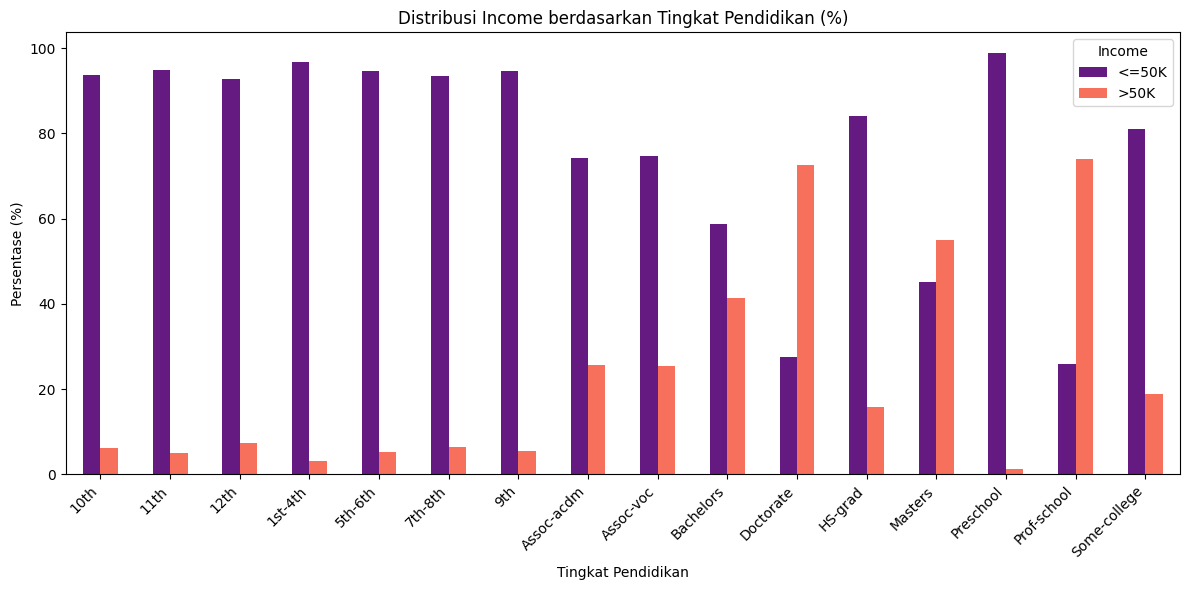

In [ ]:
palette_magma = [plt.cm.magma(0.3), plt.cm.magma(0.7)]
# Crosstab persentase
edu_income = pd.crosstab(
    df['Education'],
    df['Income'],
    normalize='index'
).mul(100)

# Plot grouped bar chart
edu_income.plot(
    kind='bar',
    figsize=(12,6),
    color=palette_magma
)

plt.title('Distribusi Income berdasarkan Tingkat Pendidikan (%)')
plt.ylabel('Persentase (%)')
plt.xlabel('Tingkat Pendidikan')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Income')
plt.tight_layout()
plt.show()


---

***Insight Distribusi Income berdasarkan Tingkat Pendidikan***

**Pendidikan Rendah (Preschool – 12th)**

* Hampir seluruh individu pada tingkat pendidikan rendah berada pada kategori **income ≤50K**.
* Proporsi **income >50K sangat kecil** (di bawah 10%).
* Hal ini menunjukkan keterbatasan peluang pendapatan tinggi pada tingkat pendidikan dasar dan menengah awal.

---

**Pendidikan Menengah (HS-grad, Some-college, Associate)**

* Mulai terlihat **peningkatan proporsi income >50K**, khususnya pada:

  * **Assoc-acdm**
  * **Assoc-voc**
* Namun, mayoritas individu masih berada pada kategori **≤50K**.
* Pendidikan menengah meningkatkan peluang pendapatan, tetapi belum dominan.

---

**Pendidikan Tinggi (Bachelors ke atas)**

* **Bachelors** menunjukkan distribusi yang lebih seimbang antara ≤50K dan >50K.
* **Masters, Doctorate, dan Prof-school** didominasi oleh individu dengan **income >50K**.
* **Doctorate dan Prof-school** memiliki proporsi income >50K paling tinggi dibandingkan tingkat pendidikan lainnya.

---

**Insight Utama**

> Terdapat hubungan yang sangat kuat antara tingkat pendidikan dan pendapatan. Semakin tinggi tingkat pendidikan, semakin besar proporsi individu dengan pendapatan di atas 50K. Pendidikan tinggi merupakan faktor yang paling konsisten dan signifikan dalam membedakan tingkat pendapatan.

---


In [ ]:
# Keterangan Aja
# Divorced : Cerai
# Married-AF-spouse : Menikah dengan pasangan anggota Angkatan Bersenjata
# Married-civ-spouse : Menikah dengan pasangan sipil
# Married-spouse-absent : Menikah, tetapi pasangan tidak tinggal bersama / tidak hadir
# Never-married : Belum pernah menikah
# Separated : Pisah (belum resmi bercerai)
# Widowed : Janda / Duda

pd.crosstab(df['Marital Status'], df['Income'], normalize='index') * 100

Income,<=50K,>50K
Marital Status,,
Divorced,89.883914,10.116086
Married-AF-spouse,62.162162,37.837838
Married-civ-spouse,55.386747,44.613253
Married-spouse-absent,90.764331,9.235669
Never-married,95.451725,4.548275
Separated,93.529412,6.470588
Widowed,91.567852,8.432148


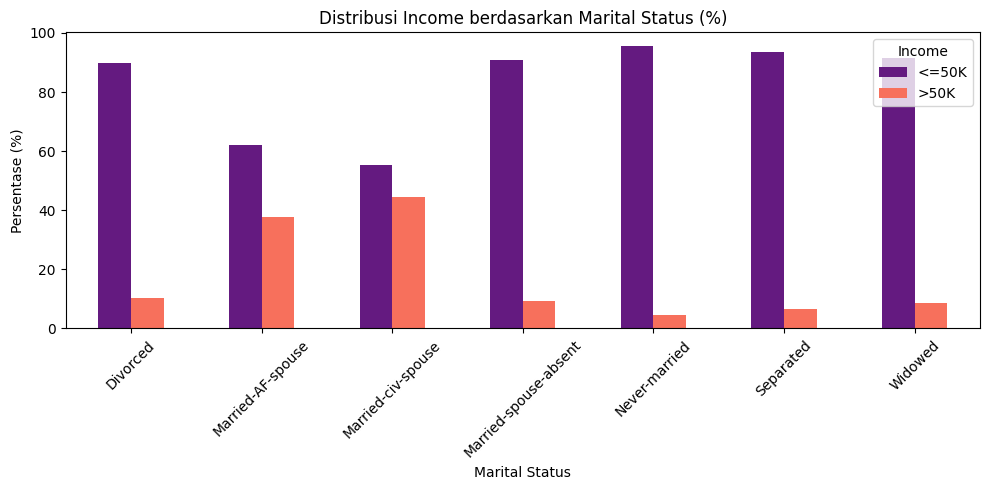

In [ ]:
palette_magma = [plt.cm.magma(0.3), plt.cm.magma(0.7)]
# Crosstab persentase
marital_income = pd.crosstab(
    df['Marital Status'],
    df['Income'],
    normalize='index'
).mul(100)

# Plot
marital_income.plot(
    kind='bar',
    figsize=(10,5),
    color=palette_magma
)

plt.title('Distribusi Income berdasarkan Marital Status (%)')
plt.ylabel('Persentase (%)')
plt.xlabel('Marital Status')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.tight_layout()
plt.show()


---

***Insight Distribusi Income berdasarkan Marital Status***

**Married-civ-spouse**

* Memiliki **proporsi income >50K tertinggi** dibandingkan status pernikahan lainnya.
* Hampir **setengah individu** dalam kategori ini berpenghasilan >50K.
* Menunjukkan bahwa individu yang menikah dengan pasangan sipil cenderung memiliki stabilitas ekonomi yang lebih baik.

---

**Married-AF-spouse**

* Proporsi income >50K juga relatif tinggi dibandingkan status lain selain married-civ-spouse.
* Menunjukkan bahwa status menikah, khususnya dengan pasangan yang bekerja (termasuk militer), berkorelasi dengan pendapatan yang lebih tinggi.

---

**Never-married**

* Didominasi oleh individu dengan **income ≤50K**.
* Proporsi income >50K sangat kecil.
* Mengindikasikan bahwa individu yang belum menikah cenderung berada pada tahap awal karier atau memiliki stabilitas ekonomi yang lebih rendah.

---

**Divorced, Separated, Widowed**

* Mayoritas individu dalam kelompok ini berada pada kategori **income ≤50K**.
* Proporsi income >50K relatif rendah dibandingkan kelompok menikah.
* Kondisi pernikahan yang tidak stabil berkorelasi dengan pendapatan yang lebih rendah.

---

**Married-spouse-absent**

* Hampir seluruh individu berada pada kategori **income ≤50K**.
* Menunjukkan bahwa status menikah tanpa kehadiran pasangan tidak memberikan keuntungan ekonomi yang signifikan.

---

**Insight Utama**

> Status pernikahan memiliki hubungan yang jelas dengan tingkat pendapatan. Individu yang menikah, khususnya **married-civ-spouse**, memiliki peluang lebih besar untuk memperoleh pendapatan di atas 50K dibandingkan individu yang belum menikah atau berada dalam kondisi pernikahan yang tidak stabil.

---


In [ ]:
pd.crosstab(df['Gender'], df['Income'], normalize='index') * 100

Income,<=50K,>50K
Gender,,
Female,89.074852,10.925148
Male,69.622347,30.377653


---
>**Kesimpulan**
- Pendidikan tinggi berpeluang pendapatan >50K
- Married-civ-spouse dominan di >50K
- Gender bias (male > female di >50K)
---

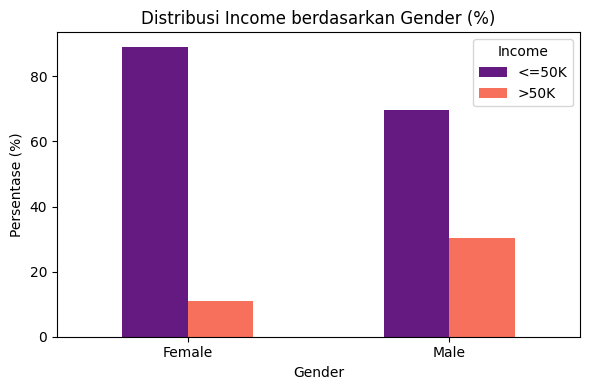

In [ ]:
palette_magma = [plt.cm.magma(0.3), plt.cm.magma(0.7)]
gender_income = pd.crosstab(
    df['Gender'],
    df['Income'],
    normalize='index'
).mul(100)

gender_income.plot(
    kind='bar',
    figsize=(6,4),
    color=palette_magma
)

plt.title('Distribusi Income berdasarkan Gender (%)')
plt.ylabel('Persentase (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.legend(title='Income')
plt.tight_layout()
plt.show()




---

***Insight Distribusi Income berdasarkan Gender***

**Female**

* Mayoritas perempuan berada pada kategori **income ≤50K**.
* Proporsi perempuan dengan **income >50K relatif kecil** (sekitar 10–12%).
* Mengindikasikan bahwa perempuan dalam dataset ini cenderung memiliki pendapatan yang lebih rendah dibandingkan laki-laki.

---

**Male**

* Proporsi laki-laki dengan **income >50K jauh lebih tinggi** dibandingkan perempuan.
* Sekitar **30% laki-laki** berada pada kategori income >50K.
* Menunjukkan adanya kecenderungan laki-laki lebih sering berada pada kelompok pendapatan tinggi.

---

 **Insight Utama**

> Terdapat perbedaan yang jelas antara gender terhadap tingkat pendapatan. Laki-laki memiliki peluang yang jauh lebih besar untuk memperoleh income >50K dibandingkan perempuan, menunjukkan adanya **gender income gap** dalam dataset ini.

---



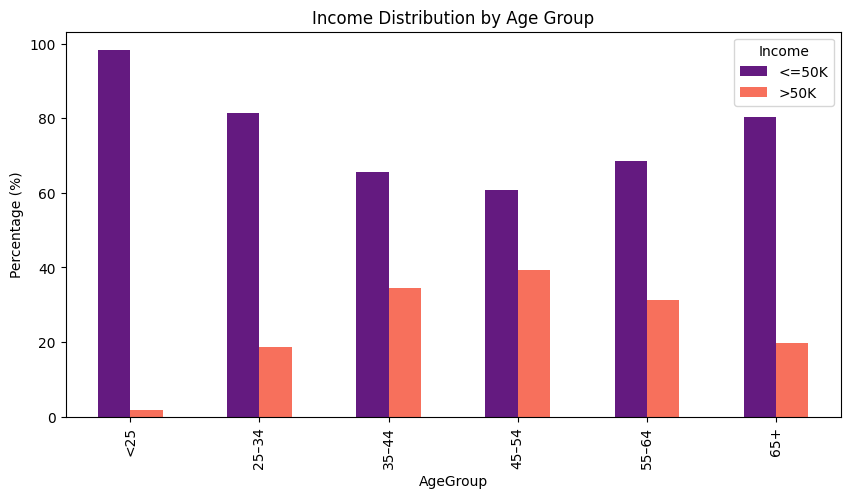

In [ ]:
palette_magma = [plt.cm.magma(0.3), plt.cm.magma(0.7)]
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,25,35,45,55,65,100],
    labels=['<25','25–34','35–44','45–54','55–64','65+'],
)

pd.crosstab(
    df['AgeGroup'],
    df['Income'],
    normalize='index'
).mul(100).plot(kind='bar', figsize=(10,5), color=palette_magma)

plt.title('Income Distribution by Age Group')
plt.ylabel('Percentage (%)')
plt.show()



---

***Insight Distribusi Income berdasarkan Kelompok Usia***

**Usia < 25 tahun**

* Hampir seluruh individu berada pada kategori **income ≤50K**.
* Proporsi income >50K **sangat kecil**.
* Wajar karena kelompok ini umumnya masih di awal karier atau belum memiliki pengalaman kerja yang panjang.

---

**Usia 25–34 tahun**

* Mulai terlihat **kenaikan proporsi income >50K**, meskipun masih didominasi oleh ≤50K.
* Menunjukkan fase **awal pertumbuhan karier**, di mana sebagian individu mulai mencapai pendapatan lebih tinggi.

---

**Usia 35–44 tahun**

* Proporsi income >50K meningkat cukup signifikan.
* Kelompok usia ini menunjukkan **transisi kuat menuju pendapatan menengah–tinggi**.
* Umumnya berada pada fase karier yang lebih stabil dan produktif.

---

**Usia 45–54 tahun**

* Merupakan **kelompok usia dengan proporsi income >50K tertinggi**.
* Menunjukkan puncak produktivitas dan posisi karier (senior/managerial level).

---

**Usia 55–64 tahun**

* Proporsi income >50K mulai **menurun**, meskipun masih relatif tinggi.
* Bisa mengindikasikan transisi menuju pensiun atau pengurangan jam kerja.

---

**Usia ≥ 65 tahun**

* Kembali didominasi oleh **income ≤50K**.
* Mengindikasikan sebagian besar individu sudah tidak berada pada puncak karier aktif.

---

**Insight Utama**

> Peluang memperoleh income >50K meningkat seiring bertambahnya usia hingga mencapai puncak pada kelompok usia **45–54 tahun**, kemudian menurun pada usia lanjut. Usia memiliki pola **non-linear** terhadap income.

---


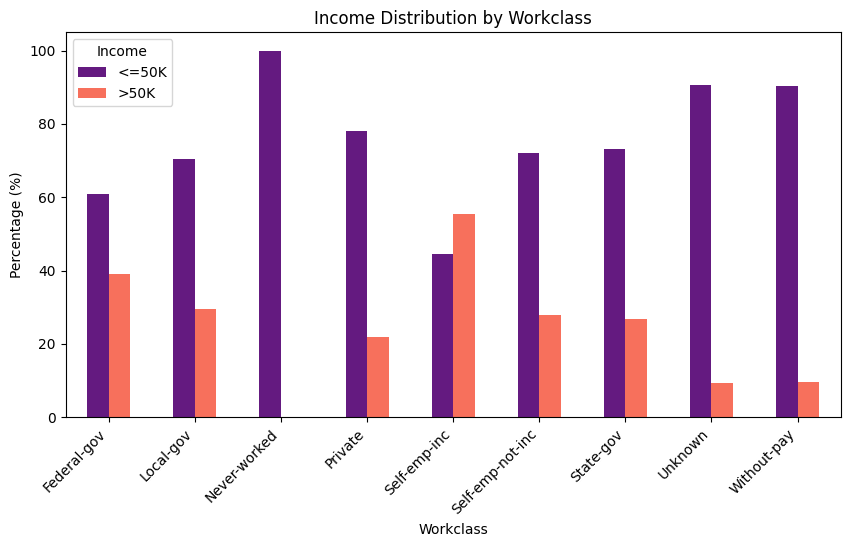

In [ ]:
palette_magma = [plt.cm.magma(0.3), plt.cm.magma(0.7)]
pd.crosstab(
    df['Workclass'],
    df['Income'],
    normalize='index'
).mul(100).plot(kind='bar', figsize=(10,5), color= palette_magma)

plt.title('Income Distribution by Workclass')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.show()


---

***Insight Distribusi Income berdasarkan Workclass***

**Self-emp-inc (Wiraswasta dengan badan usaha)**

* Memiliki **proporsi income >50K tertinggi** dibanding workclass lain.
* Menunjukkan bahwa kepemilikan usaha berbadan hukum berkorelasi dengan pendapatan tinggi.
* Kelompok ini berpotensi memiliki **kontrol lebih besar terhadap sumber pendapatan**.

---

**Federal-gov & Local-gov**

* Menunjukkan proporsi income >50K yang **relatif tinggi dan stabil**.
* Mengindikasikan bahwa pekerjaan pemerintahan cenderung memberikan **keamanan dan struktur gaji yang lebih baik**.

---

**Private**

* Merupakan workclass dengan jumlah individu terbesar, namun **didominasi income ≤50K**.
* Meski ada individu berpendapatan tinggi, secara proporsi masih kalah dibanding self-employed atau federal government.
* Menggambarkan **ketimpangan pendapatan di sektor swasta**.

---

**Self-emp-not-inc**

* Proporsi income >50K **lebih rendah dibanding self-emp-inc**.
* Menunjukkan bahwa wiraswasta tanpa badan usaha memiliki **risiko pendapatan lebih besar**.

---

**Never-worked & Without-pay**

* Hampir **100% berada pada income ≤50K**.
* Secara logis tidak berkontribusi pada pendapatan tinggi.
* Perlu dipertimbangkan untuk:

  * digabungkan
  * atau diperlakukan sebagai kategori khusus saat modeling

---

**Unknown**

* Didominasi oleh income ≤50K.
* Kemungkinan mencerminkan:

  * data tidak lengkap
  * pekerjaan informal

---

 **Insight Utama**

> Workclass memiliki pengaruh kuat terhadap income. Individu yang bekerja sebagai **self-employed dengan badan usaha** atau di **sektor pemerintahan** memiliki peluang lebih besar untuk memperoleh income >50K dibandingkan pekerja sektor swasta atau informal.

---
